In [1]:
from FormUtils import pyForm, capture_physics_expr

In [2]:
%%pyForm ee_to_mumu_noM

* Process: e+ e- -> mu+ mu-
#-
* Above suppresses extra output
Off Statistics;
Off FinalStats;

#include SquareAmplitude.h

* Physical constants
Symbols e, pi, alpha;

Local M = (e^2) * (VB(i1, p2, 0) * g(i1, i2, mu1) * U(i2, p1, 0)) *  phprop(mu1, mu2, q)  * (UB(i3, p3, 0) * g(i3, i4, mu2) * V(i4, p4, 0));
#call squareamplitude(M, Msq)
.sort
* Spin averaging (1/2 * 1/2)
multiply 1/4; 
* coupling
id e^4 = 16 * pi^2 * alpha^2;
* propagator handling
id q = p1 + p2;
id prop(x?) = (x)^-1;
id (q.q)^-1 = (s)^-1;
.sort

* Kinematics 
repeat;

    id p1.p1 = 0;
    id p2.p2 = 0;
    id p3.p3 = 0;
    id p4.p4 = 0;
    
    id p1.p2 = (s - p1.p1 - p2.p2)/2;
    id p3.p4 = (s - p3.p3 - p4.p4)/2;
    
    
    id p1.p3 = (p1.p1 + p3.p3 - t)/2;
    id p2.p4 = (p2.p2 + p4.p4 - t)/2;

   
    id p1.p4 = (p1.p1 + p4.p4 - u)/2;
    id p2.p3 = (p2.p2 + p3.p3 - u)/2;
endrepeat;
.sort

bracket alpha, s;
.sort
* Save
Format C;
#write <ee_to_mumu_noM.txt> "%e;", Msq;
.sort
* Print
Format;
Print Msq;
.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Tue Apr 14 18:40:16 2026
    
    * Process: e+ e- -> mu+ mu-
    #-

   Msq =
      32*s^(-2)*u^2*pi^2*alpha^2 + 32*s^(-2)*t^2*pi^2*alpha^2;




<|M^2|> =  32*pi**2*alpha**2*(t**2 + u**2)/s**2
dsigma/dOmega CM =  alpha**2*(cos(theta)**2 + 1)/(4*s)


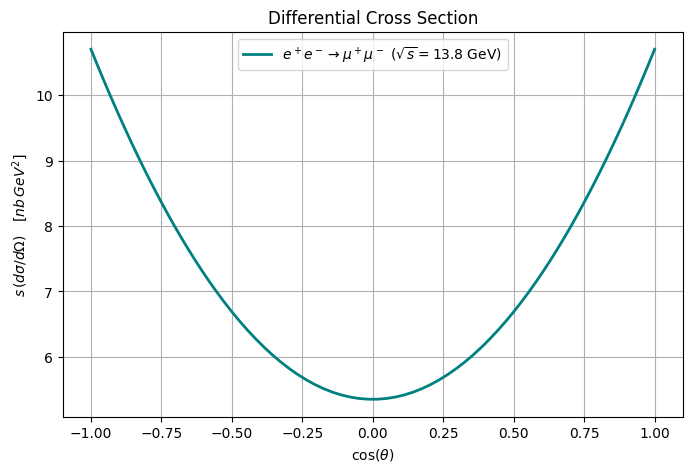

In [3]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from Kinematics import XS_2To2_CM

plt.style.use("seaborn-v0_8-muted")
plt.rcParams["axes.grid"] = True

# Capture Raw FORM ouput
form_expr = capture_physics_expr("scripts/ee_to_mumu_noM.txt")
# Convert FORM to sympy
s, alpha, Mass = sp.symbols("s alpha Mass")
t,u = sp.symbols("t u")
Msq = sp.simplify(form_expr)
print(f"<|M^2|> =  {Msq}")

# Call the method to get the xs in CM
theta = sp.Symbol("theta", real=True)
xs = XS_2To2_CM(Msq, s, t, u, theta, 0, 0, 0, 0)
print(f"dsigma/dOmega CM =  {xs}")

# lambdify
xs_lambda = sp.lambdify((s, alpha, theta), xs, "numpy")

# inputs
sqrtS = 13.8
sVal = sqrtS * sqrtS
# Running of alpha
alphaVal = (1 / 137.036) / (
    1 - (1 / (137.036 * 3 * np.pi)) * np.log(sqrtS**2 / 5.11e-4**2)
)
# (0.197327 GeV * fm)^2 = 0.0389379 GeV^2 * fm^2
# 1 GeV^-2 = 0.389379 mb (millibarns)
conv_gev2_to_nb = 389379.0

# Fill values for Plotting
angles = np.linspace(0, np.pi, 100)
x_vals = np.cos(angles)
y_vals = xs_lambda(sVal, alphaVal, angles)
y_vals = (sqrtS**2) * y_vals * conv_gev2_to_nb

# Plot
plt.figure(figsize=(8, 5))
plt.plot(
    x_vals,
    y_vals,
    lw=2,
    color="teal",
    label=rf"$e^+e^- \to \mu^+\mu^-$ ($\sqrt{{s}}={(sqrtS)}$ GeV)",
)
plt.title("Differential Cross Section")
plt.xlabel(r"$\cos(\theta)$")
plt.ylabel(r"$s\, (d\sigma/d\Omega)\quad [nb\, GeV^2]$ ")
plt.legend()
plt.show()